In [1]:
import torch
import matplotlib.pyplot as plt
import os
import time
import numpy as np
import random
from matplotlib.patches import Rectangle
import tifffile
import h5py
from torch.utils.data import DataLoader
import imageio.v2 as imageio
from scipy.ndimage import gaussian_filter

import importlib as imp
import sys
sys.path.append('/home/abenneck/Desktop/yolo_tiles/docs/scripts')

import yolo_tiles
imp.reload(yolo_tiles)
from yolo_tiles import img_to_tiles, apply_model_to_tiles, load_test_image, preprocess, tileDataset, remove_bbox_in_overlap

import yolo_help
imp.reload(yolo_help)
from yolo_help import bbox_to_rectangles, imshow, convert_data, Net, get_best_bounding_box_per_cell

import yolo_post_help
imp.reload(yolo_post_help)
from yolo_post_help import remove_low_conf_bboxes, postprocess, bb_to_rec

import yolo_help_3D
imp.reload(yolo_help_3D)
from yolo_help_3D import apply_model_to_orthogonal_slices, gen_3D_GT, recon_down, vol_to_mip_rgb, orthogonal_to_3D

# (0) Apply 2D model to 3D volume of 2D coronal slices

## (0.0) Extract a 3D volume from a stack of 2D slices

In [2]:
img_dir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/Ex_488_Em_525_stitched'
outdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_outputs_v05/'

In [3]:
idx_start = 1500 # Entire slice clearly visible after gamma correction
n_slice = 120 # The number of slices to generate a cube
tile_idx = 2077 # This tile has an anchor point of ~(10_000, 7_500)
last_idx = 120

for idx, fname in enumerate(sorted(os.listdir(img_dir))[(idx_start):(idx_start+n_slice)]):

    if idx < last_idx:
        continue
        
    # Load the image
    img_path = os.path.join(img_dir, fname)
    img = tifffile.imread(img_path)
        
    # Preprocess using gamma correction + upsampling
    start = time.time()
    img_up = preprocess(img)
    print(f'Finished preprocessing in {time.time()-start:.2f}s')

    # Extract tiles from the preprocessed input image
    padded_img, tiles = img_to_tiles(img_up, lower_threshold_bg = 0.04, verbose=True)
    I_tile = tiles[tile_idx]['img']
    np.save(os.path.join(outdir, f'slice_{idx}.npy'), I_tile)
    
    print(f'Finished {idx}/{n_slice}\n')

## (0.1) Stack + interpolate the slices to have one isotropic cube of data

In [4]:
# Load and stack all the extracted tiles
slice_dir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_outputs_v05/'
vol = []
for fname in os.listdir(slice_dir):
    I = np.load(os.path.join(slice_dir, fname))
    vol.append(I)
vol_stacked = np.stack(vol, axis=2)

In [5]:
# Generate a gif of all the slices
if False:
    frames = []
    for fname in os.listdir(slice_dir):
        img = np.load(os.path.join(slice_dir, fname))
        x = img.astype(np.float32)
        x -= x.min()
        x /= (x.max() if x.max() > 0 else 1.0)
        img_u8 = (x * 255).astype(np.uint8)
        frames.append(img_u8)
    
    imageio.mimsave('/home/abenneck/Desktop/vol.gif', frames, duration = 100, loop=0)

In [6]:
# Interpolate along the z-axis
from scipy.ndimage import map_coordinates
tile_dim = 256

x = np.arange(tile_dim)
y = np.arange(tile_dim)
z = np.linspace(0, n_slice-1, tile_dim)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
coords = np.array([X, Y, Z])
vol_interp = map_coordinates(vol_stacked, coords, order=3)
vol_interp.shape

(256, 256, 256)

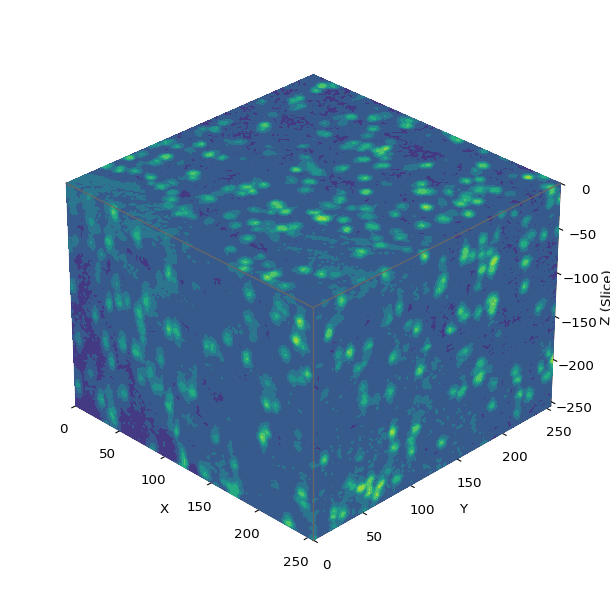

In [7]:
# Generate a 3D view of the interpolated data

# Define dimensions and grid
Nx, Ny, Nz = 256, 256, 256
X, Y, Z = np.meshgrid(np.arange(Nx), np.arange(Ny), -np.arange(Nz))
kw = {'vmin': vol_interp.min(), 'vmax': vol_interp.max(), 'levels': np.linspace(vol_interp.min(), vol_interp.max(), 10)}

# Create a figure with 3D ax
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Plot contour surfaces
_ = ax.contourf(
    X[:, :, 0], Y[:, :, 0], vol_interp[:, :, 0],
    zdir='z', offset=0, **kw)

_ = ax.contourf(
    X[0, :, :], vol_interp[0, :, :], Z[0, :, :],
    zdir='y', offset=0, **kw)

C = ax.contourf(
    vol_interp[:, -1, :], Y[:, -1, :], Z[:, -1, :],
    zdir='x', offset=X.max(), **kw)

# Set limits of the plot from coord limits
xmin, xmax = X.min(), X.max()
ymin, ymax = Y.min(), Y.max()
zmin, zmax = Z.min(), Z.max()
ax.set(xlim=[xmin, xmax], ylim=[ymin, ymax], zlim=[zmin, zmax])

# Plot edges
edges_kw = dict(color='0.4', linewidth=1, zorder=1e3)
ax.plot([xmax, xmax], [ymin, ymax], 0, **edges_kw)
ax.plot([xmin, xmax], [ymin, ymin], 0, **edges_kw)
ax.plot([xmax, xmax], [ymin, ymin], [zmin, zmax], **edges_kw)

# Set labels and zticks
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z (Slice)')
ax.view_init(30, -45, 0)
ax.set_box_aspect(None, zoom=0.9)

# Show Figure
plt.show()

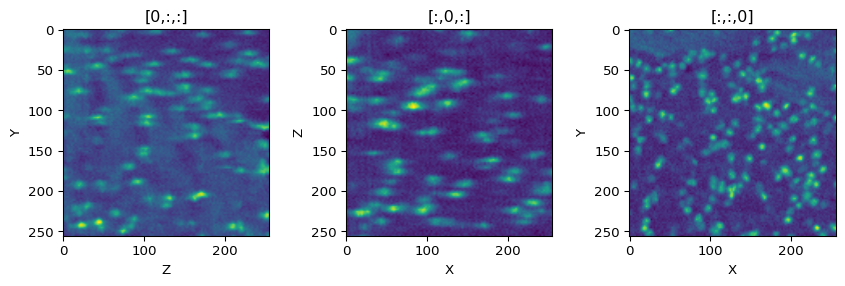

In [8]:
fig, ax = plt.subplots(1,3, layout='tight')
ax[0].imshow(vol_interp[0,:,:])
ax[0].set_title('[0,:,:]')
ax[0].set_xlabel('Z')
ax[0].set_ylabel('Y')

ax[1].imshow(vol_interp[:,0,:])
ax[1].set_title('[:,0,:]')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Z')

ax[2].imshow(vol_interp[:,:,0])
ax[2].set_title('[:,:,0]')
ax[2].set_xlabel('X')
ax[2].set_ylabel('Y')

fig.set_size_inches(9,3)

## (0.2) Apply the network to each slice along all 3 cardinal planes

In [9]:
# Load the pretrained model
model_path = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_saved_weights/modelsave_bright_on_dark.pt'
net = Net()
net.load_state_dict(torch.load(model_path))

# Define some hyperparameters
ds_factor = 8
bbox_dim = 5
num_classes = 3
B = net.B
stride = net.stride
dtype = torch.float32
pads = np.array([0,0])

# Initialize reconstruction containers
recon_xy = np.ones((int(tile_dim/ds_factor), int(tile_dim/ds_factor), tile_dim, bbox_dim+num_classes))*(-np.inf)
recon_xz = np.ones((int(tile_dim/ds_factor), tile_dim, int(tile_dim/ds_factor), bbox_dim+num_classes))*(-np.inf)
recon_yz = np.ones((tile_dim, int(tile_dim/ds_factor), int(tile_dim/ds_factor), bbox_dim+num_classes))*(-np.inf)

start = time.time()
for idx in np.arange(tile_dim):
    slice_xy = vol_interp[:,:,idx][None]
    slice_xz = vol_interp[:,idx,:][None]
    slice_yz = vol_interp[idx,:,:][None]

    # Apply model to slices parallel to the XY-plane
    out_xy = net((torch.tensor(slice_xy[None],dtype=dtype)))
    out_xy = out_xy[0].detach().numpy()
    out_xy = postprocess(out_xy, B, stride, pads, up_factor=1)
    recon_xy[:,:,idx,:] = out_xy

    # Apply model to slices parallel to the XZ-plane
    out_xz = net((torch.tensor(slice_xz[None],dtype=dtype)))
    out_xz = out_xz[0].detach().numpy()
    out_xz = postprocess(out_xz, B, stride, pads, up_factor=1)
    recon_xz[:,idx,:,:] = out_xz   
    
    # Apply model to slices parallel to the YZ-plane
    out_yz = net((torch.tensor(slice_yz[None],dtype=dtype)))
    out_yz = out_yz[0].detach().numpy()
    out_yz = postprocess(out_yz, B, stride, pads, up_factor=1)
    recon_yz[idx,:,:,:] = out_yz    

    if idx % 25 == 0:
        print(f'Finished {idx}/{tile_dim}')

print(f'Finished applying model to 3 orthogonal views in {time.time()-start:.2f}s')

Finished 0/256
Finished 25/256
Finished 50/256
Finished 75/256
Finished 100/256
Finished 125/256
Finished 150/256
Finished 175/256
Finished 200/256
Finished 225/256
Finished 250/256
Finished applying model to 3 orthogonal views in 14.46s


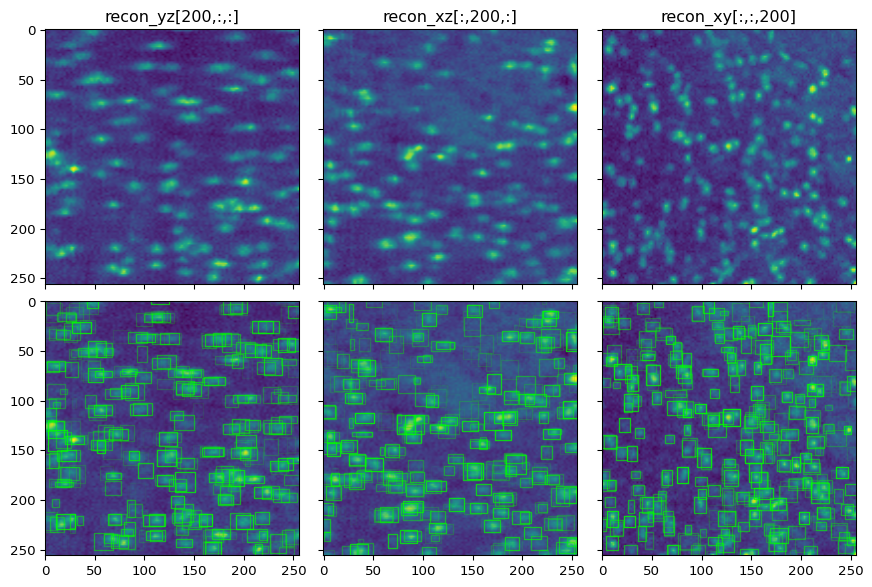

In [10]:
slice_idx = 200

nrow, ncol = 2, 3
fig, axs = plt.subplots(nrow, ncol, layout='constrained', sharex=True, sharey=True)

axs[0,0].imshow(vol_interp[slice_idx,:,:])
axs[1,0].imshow(vol_interp[slice_idx,:,:])
bb = recon_yz[slice_idx,:,:,:]
scores = recon_yz[slice_idx,:,:,-4]
predicted_rectangles = bb_to_rec(bb, fc='none', ec='lime', alpha=scores)
axs[1,0].add_collection(predicted_rectangles)
axs[0,0].set_title(f'recon_yz[{slice_idx},:,:]')

axs[0,1].imshow(vol_interp[:,slice_idx,:])
axs[1,1].imshow(vol_interp[:,slice_idx,:])
bb = recon_xz[:,slice_idx,:,:]
scores = recon_xz[:,slice_idx,:,-4]
predicted_rectangles = bb_to_rec(bb, fc='none', ec='lime', alpha=scores)
axs[1,1].add_collection(predicted_rectangles)
axs[0,1].set_title(f'recon_xz[:,{slice_idx},:]')

axs[0,2].imshow(vol_interp[:,:,slice_idx])
axs[1,2].imshow(vol_interp[:,:,slice_idx])
bb = recon_xy[:,:,slice_idx,:]
scores = recon_xy[:,:,slice_idx,-4]
predicted_rectangles = bb_to_rec(bb, fc='none', ec='lime', alpha=scores)
axs[1,2].add_collection(predicted_rectangles)
axs[0,2].set_title(f'recon_xy[:,:,{slice_idx}]')

fig.set_size_inches(ncol*3, nrow*3)

## (0.3) Downsample the outputs along the 'tile_dim' axis

In [11]:
conf_idx = 4
ds_factor = 8
down_dim = int(tile_dim/ds_factor)

down_xy = []
down_xz = []
down_yz = []

start = time.time()
for idx in np.arange(down_dim):

    # Extract subset of 8 XY-slices to be downsampled into 1 slice
    recon_xy_down = recon_xy[:,:,(idx*ds_factor):((idx+1)*ds_factor),:]

    # Get idx of bbox with highest confidence at each pixel
    inds_xy = np.argmax(recon_xy_down[..., conf_idx], axis = 2)

    # Downsample along relevant axis using the above indeces
    recon_xy_down = np.take_along_axis(recon_xy_down, inds_xy[:, :, None, None], axis=2)

    # Append downsampled slice to final output for XY-slices
    down_xy.append(recon_xy_down)

    # Repeat for XZ-slices
    recon_xz_down = recon_xz[:,(idx*ds_factor):((idx+1)*ds_factor),:,:]
    inds_xz = np.argmax(recon_xz_down[..., conf_idx], axis = 1)
    recon_xz_down = np.take_along_axis(recon_xz_down, inds_xz[:, None, :, None], axis=1)
    down_xz.append(recon_xz_down)

    # Repear for YZ-slices
    recon_yz_down = recon_yz[(idx*ds_factor):((idx+1)*ds_factor),:,:,:]
    inds_yz = np.argmax(recon_yz_down[..., conf_idx], axis = 0)
    recon_yz_down = np.take_along_axis(recon_yz_down, inds_yz[None, :, :, None], axis=0)
    down_yz.append(recon_yz_down)

# Concat lists so that they are now each 32x32x32 cubes
down_xy = np.concatenate(down_xy, axis=2)
down_xz = np.concatenate(down_xz, axis=1)
down_yz = np.concatenate(down_yz, axis=0)

print(f'Finished downsampling outputs in {time.time()-start:.2f}s')

Finished downsampling outputs in 0.02s


In [18]:
# Downsample vol_interp along one axis. Useful for overlaying bbox outputs on MIPs
def vol_to_mip(vol, ax_idx, ds_factor = 8):
    """
    Convert a 3D image volume (vol) into a stack of 2D MIPs along an axis (ax_idx). 
    This is useful for visualizing outputs from the YOLO_3D pipeline.

    Parameters:
    ===========
    vol : array of shape 256x256x256
        The image volume to be 'downsampled'
    ax_idx : int
        The axis along which MIPs should be generated
    ds_factor : int
        The number of slices to use in each MIP

    Returns:
    ========
    vol_mip : array 
        A stack of MIPs along the 'ax_idx' axis
    """
    vol_mip = []
    vol_dim = vol.shape[ax_idx]
    for i in np.arange(int(vol_dim/ds_factor)):
        
        if ax_idx == 0:
            vol_slice_stack = vol[(i*ds_factor):((i+1)*ds_factor), :, :]
        elif ax_idx == 1:
            vol_slice_stack = vol[:, (i*ds_factor):((i+1)*ds_factor), :]
        elif ax_idx == 2:
            vol_slice_stack = vol[:, :, (i*ds_factor):((i+1)*ds_factor)]
        else:
            raise Exception(f'vol only has {len(vol.shape)} axes, but ax_idx = {ax_idx} was passed')
            
        vol_slice_max = np.max(vol_slice_stack, axis=ax_idx)
        vol_mip.append(vol_slice_max)
            
    vol_mip = np.stack(vol_mip, axis=ax_idx)
    return vol_mip

vol_0 = vol_to_mip(vol_interp, 0)
vol_1 = vol_to_mip(vol_interp, 1)
vol_2 = vol_to_mip(vol_interp, 2)

In [13]:
print('recon_output.shape => downsampled_output.shape')
print(f'xy: {recon_xy.shape} => {down_xy.shape}')
print(f'xz: {recon_xz.shape} => {down_xz.shape}')
print(f'yz: {recon_yz.shape} => {down_yz.shape}\n')

print('vol_interp.shape => vol_mip.shape')
print(f'xy: {vol_interp.shape} => {vol_0.shape}')
print(f'xz: {vol_interp.shape} => {vol_1.shape}')
print(f'yz: {vol_interp.shape} => {vol_2.shape}')

recon_output.shape => downsampled_output.shape
xy: (32, 32, 256, 8) => (32, 32, 32, 8)
xz: (32, 256, 32, 8) => (32, 32, 32, 8)
yz: (256, 32, 32, 8) => (32, 32, 32, 8)

vol_interp.shape => vol_mip.shape
xy: (256, 256, 256) => (32, 256, 256)
xz: (256, 256, 256) => (256, 32, 256)
yz: (256, 256, 256) => (256, 256, 32)


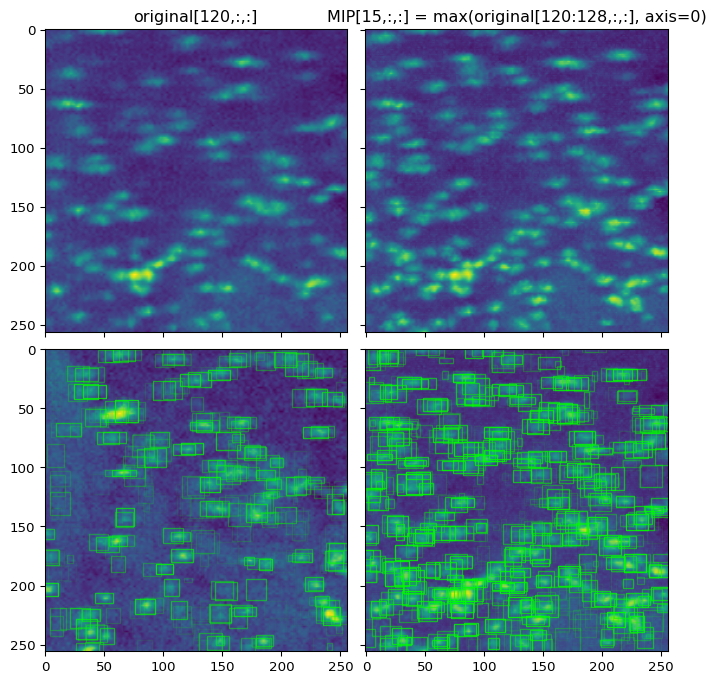

In [14]:
slice_idx = 15 # 0:32
ds_factor = 8
orig_slice_idx = slice_idx*ds_factor # 0:256

fig, axs = plt.subplots(2, 2, layout='constrained', sharex=True, sharey=True)
axs[0,0].imshow(vol_interp[orig_slice_idx,:,:])
axs[0,0].set_title(f'original[{orig_slice_idx},:,:]')

scores = recon_yz[slice_idx,:,:,-4].ravel()
predicted_rectangles = bb_to_rec(recon_yz[slice_idx,:,:,:], fc='none', ec='lime', alpha=scores)
axs[1,0].imshow(vol_interp[slice_idx,:,:])
axs[1,0].add_collection(predicted_rectangles)

axs[0,1].imshow(vol_0[slice_idx,:,:])
axs[0,1].set_title(f'MIP[{slice_idx},:,:] = max(original[{orig_slice_idx}:{orig_slice_idx+8},:,:], axis=0)')

scores = down_yz[slice_idx,:,:,-4].ravel()
predicted_rectangles = bb_to_rec(down_yz[slice_idx,:,:,:], fc='none', ec='lime', alpha=scores)
axs[1,1].imshow(vol_0[slice_idx,:,:])
axs[1,1].add_collection(predicted_rectangles)

fig.set_size_inches(7,7)

## (0.4) Stitch together 3 2D outputs into 1 3D output of the same shape

In [37]:
start = time.time()

bbox_dim = 7
recon_total = np.ones((down_dim, down_dim, down_dim, bbox_dim+num_classes))*(-np.inf)
for i in np.arange(down_dim):
    for j in np.arange(down_dim):
        for k in np.arange(down_dim):
        
            # From meeting 02/26/26
            xmin = (down_xy[i,j,k,1] + down_xz[i,j,k,1]) / 2
            xmax = (down_xy[i,j,k,3] + down_xz[i,j,k,3]) / 2
            ymin = (down_xy[i,j,k,0] + down_yz[i,j,k,1]) / 2
            ymax = (down_xy[i,j,k,2] + down_yz[i,j,k,3]) / 2
            zmin = (down_xz[i,j,k,0] + down_yz[i,j,k,0]) / 2
            zmax = (down_xz[i,j,k,2] + down_yz[i,j,k,2]) / 2
            
            # conf = np.max([down_xy[i,j,k,4], down_xz[i,j,k,4], down_yz[i,j,k,4]])
            # conf = np.min([down_xy[i,j,k,4], down_xz[i,j,k,4], down_yz[i,j,k,4]])
            conf = down_xy[i,j,k,4] * down_xz[i,j,k,4] * down_yz[i,j,k,4]
            # conf = np.sum([down_xy[i,j,k,4], down_xz[i,j,k,4], down_yz[i,j,k,4]]) / 3
            
            cl0 = np.max([down_xy[i,j,k,5], down_xz[k,i,j,5], down_yz[j,k,i,5]])
            cl1 = np.max([down_xy[i,j,k,6], down_xz[k,i,j,6], down_yz[j,k,i,6]])
            cl2 = np.max([down_xy[i,j,k,7], down_xz[k,i,j,7], down_yz[j,k,i,7]])
            
            recon_total[i,j,k] = [xmin, xmax, ymin, ymax, zmin, zmax, conf, cl0, cl1, cl2]

print(f'Finished combining outputs in {time.time()-start:.2f}s')

Finished combining outputs in 0.66s


### Summary Statistics

In [38]:
print('Bbox details')
print(f'np.min(xmin): {np.min(recon_total[:,:,:,0])}')
print(f'np.max(xmax): {np.max(recon_total[:,:,:,1])}')
print(f'np.min(ymin): {np.min(recon_total[:,:,:,2])}')
print(f'np.max(ymax): {np.max(recon_total[:,:,:,3])}')
print(f'np.min(zmin): {np.min(recon_total[:,:,:,4])}')
print(f'np.max(zmax): {np.max(recon_total[:,:,:,5])}')
print()

print('Conf details')
print(f'min: {np.min(recon_total[:,:,:,-4])}')
print(f'max: {np.max(recon_total[:,:,:,-4])}')
print(f'avg: {np.average(recon_total[:,:,:,-4])}')
print(f'std: {np.std(recon_total[:,:,:,-4])}')
print()

print('Data at [0,0,0]')
print(recon_total[0,0,0])

Bbox details
np.min(xmin): -8.238142013549805
np.max(xmax): 262.76905822753906
np.min(ymin): -7.571131229400635
np.max(ymax): 262.87811279296875
np.min(zmin): -7.786772727966309
np.max(zmax): 263.6905975341797

Conf details
min: 4.639359041831663e-53
max: 0.6652349433787457
avg: 0.054715814889773895
std: 0.11211835098978983

Data at [0,0,0]
[-5.61961627e+00  9.99296999e+00 -4.26669455e+00  1.24777112e+01
  1.43471456e+00  7.24990344e+00  7.90833776e-05  3.27794075e-01
 -2.78825045e-01 -2.23635584e-01]


## (0.5) Visualize the outputs

Plotting bboxes . . .


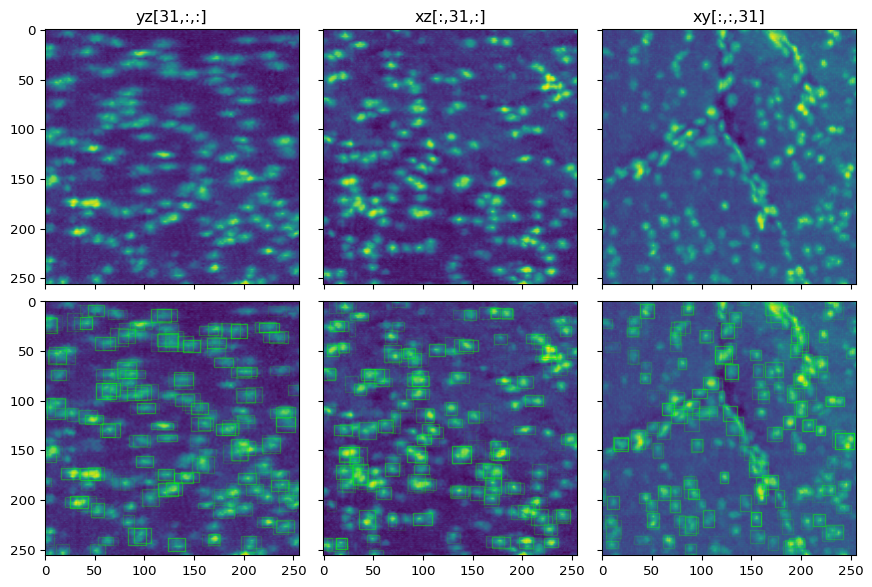

In [39]:
slice_idx = 31 # 0:31

outdir = '/home/abenneck/Desktop/yolo3d_outputs/gif_frames_0'
# for slice_idx in np.arange(down_dim):

nrow, ncol = 2, 3
fig, axs = plt.subplots(nrow, ncol, layout='constrained', sharex=True, sharey=True)
axs[0,0].imshow(vol_0[slice_idx,:,:])
axs[0,0].set_title(f'yz[{slice_idx},:,:]')
axs[0,1].imshow(vol_1[:,slice_idx,:])
axs[0,1].set_title(f'xz[:,{slice_idx},:]')
axs[0,2].imshow(vol_2[:,:,slice_idx])
axs[0,2].set_title(f'xy[:,:,{slice_idx}]')

print('Plotting bboxes . . .')

scores = recon_total[slice_idx,:,:,-4].ravel()
predicted_rectangles = bb_to_rec(recon_total[slice_idx,:,:,:], pos = [4,2,5,3], fc='none', ec='lime', alpha=scores)
axs[1,0].imshow(vol_0[slice_idx,:,:])
axs[1,0].add_collection(predicted_rectangles)

scores = recon_total[:,slice_idx,:,-4].ravel()
predicted_rectangles = bb_to_rec(recon_total[:,slice_idx,:,:], pos = [4,0,5,1], fc='none', ec='lime', alpha=scores)
axs[1,1].imshow(vol_1[:,slice_idx,:])
axs[1,1].add_collection(predicted_rectangles)

scores = recon_total[:,:,slice_idx,-4].ravel()
predicted_rectangles = bb_to_rec(recon_total[:,:,slice_idx,:], pos = [2,0,3,1], fc='none', ec='lime', alpha=scores)
axs[1,2].imshow(vol_2[:,:,slice_idx])
axs[1,2].add_collection(predicted_rectangles)

fig.set_size_inches(ncol*3, nrow*3)
# plt.savefig(os.path.join(outdir, f'recon_slice_{slice_idx:03d}.png'))

In [33]:
# Generate a gif of all the slices
if False:
    frames = []
    for fname in sorted(os.listdir(outdir)):
        if '.ipynb' not in fname:
            img = imageio.imread(os.path.join(outdir, fname))
            frames.append(img)
    
    imageio.mimsave('/home/abenneck/Desktop/yolo3d_outputs/gif0.gif', frames, duration = 1000, loop=0)

# (1) Quantify model performance on a 3D simulated dataset

## (1.1) Initialize a 3D volume w/ cells + artifacts

In [7]:
def gen_3D_GT(N, M, nclasses, thr_rel=0.15):
    """
    Generate a synthetic 3D volume with ellipsoidal blobs ("cells") and several artifacts
    commonly found in natural microscopy data.

    Output volume is channels-last: (Z, Y, X, d).

    Bounding boxes are computed by:
      1) Synthesizing each object's mask in a local ROI
      2) Thresholding the mask at (thr_rel * max(mask))
      3) Taking the tight axis-aligned bounding box of the thresholded support

    Parameters
    ----------
    N : int
        Spatial size for X, Y, and Z (volume is N x N x N).
    M : int
        Upper bound for number of objects (m = 1 + randint(M)).
    nclasses : int
        Number of classes (labels in [0, nclasses-1]).
    thr_rel : float
        Relative threshold for bbox extraction: keep = mask > thr_rel * mask.max().

    Returns
    -------
    I : np.ndarray
        Image volume of shape (N, N, N, d) float32  (Z, Y, X, d)
    bbox : np.ndarray
        Bounding boxes of shape (m, 6) float32
        Each row: (x0, y0, z0, w, h, depth) with half-open extents
    cl : np.ndarray
        Class labels of shape (m,)
    """
    # number of channels
    d = 3
    bg = np.random.rand(d).astype(np.float32)

    # channels-last volume: (Z, Y, X, d)
    I = np.zeros((N, N, N, d), dtype=np.float32) + bg[None, None, None, :]

    # how many objects
    m = 1 + np.random.randint(M)
    cl = np.random.randint(0, nclasses, size=m)

    # centers in voxel coordinates: (x, y, z)
    c = (np.random.rand(m, 3) * (np.array([N, N, N]) - 1)).astype(np.float32)

    # sizes (sigmas) per axis: (sx, sy, sz)
    s = (3 + np.random.rand(m, 3) * 20).astype(np.float32)

    # Euler angles (rx, ry, rz)
    angles = (np.random.rand(m, 3) * 2 * np.pi).astype(np.float32)

    color0 = np.random.rand(d).astype(np.float32)
    bbox = np.zeros((m, 6), dtype=np.float32)

    def euler_R(rx, ry, rz):
        """Rotation matrix R = Rz @ Ry @ Rx."""
        cx, sx = np.cos(rx), np.sin(rx)
        cy, sy = np.cos(ry), np.sin(ry)
        cz, sz = np.cos(rz), np.sin(rz)

        Rx = np.array([[1, 0, 0],
                       [0, cx, -sx],
                       [0, sx,  cx]], dtype=np.float32)
        Ry = np.array([[ cy, 0, sy],
                       [  0,  1,  0],
                       [-sy, 0, cy]], dtype=np.float32)
        Rz = np.array([[cz, -sz, 0],
                       [sz,  cz, 0],
                       [ 0,   0, 1]], dtype=np.float32)
        return (Rz @ Ry @ Rx).astype(np.float32)

    for i in range(m):
        cx, cy, cz = c[i]
        sx_, sy_, sz_ = s[i]
        cli = int(cl[i])
        R = euler_R(*angles[i])

        # ROI for synthesis: center +/- 3*max(sigma)
        mxi = float(max(sx_, sy_, sz_))
        left   = int(np.clip(cx - 3*mxi, 0, N - 1))
        right  = int(np.clip(cx + 3*mxi, 0, N - 1))
        top    = int(np.clip(cy - 3*mxi, 0, N - 1))
        bottom = int(np.clip(cy + 3*mxi, 0, N - 1))
        front  = int(np.clip(cz - 3*mxi, 0, N - 1))
        back   = int(np.clip(cz + 3*mxi, 0, N - 1))

        # enforce non-empty half-open ranges
        right  = max(right,  left + 1)
        bottom = max(bottom, top + 1)
        back   = max(back,   front + 1)

        # local coordinate blocks (broadcasted)
        zz = (np.arange(front, back, dtype=np.float32) - cz)[:, None, None]   # (Dz,1,1)
        yy = (np.arange(top, bottom, dtype=np.float32) - cy)[None, :, None]   # (1,Dy,1)
        xx = (np.arange(left, right, dtype=np.float32) - cx)[None, None, :]   # (1,1,Dx)

        # rotate into object frame: P' = R^T P
        Xp = R[0, 0]*xx + R[1, 0]*yy + R[2, 0]*zz
        Yp = R[0, 1]*xx + R[1, 1]*yy + R[2, 1]*zz
        Zp = R[0, 2]*xx + R[1, 2]*yy + R[2, 2]*zz

        # ellipsoidal metric
        q = (Xp/(sx_ + 1e-6))**2 + (Yp/(sy_ + 1e-6))**2 + (Zp/(sz_ + 1e-6))**2
        base = (q/2.0)*(3.0**2)

        # class-dependent mask shape + optional bumps
        if cli <= 1:
            mask = np.exp(-(base)**(1 + 2*cli)).astype(np.float32)
        else:
            mask = np.exp(-(base)**4).astype(np.float32)
            bumps = gaussian_filter(np.random.randn(*mask.shape).astype(np.float32), 1)
            mask *= np.exp(bumps).astype(np.float32)

        # add object to volume
        color = (color0*0.95 + np.random.rand(d).astype(np.float32)*0.05).astype(np.float32)
        I[front:back, top:bottom, left:right, :] += mask[..., None] * color[None, None, None, :]

        # bbox from thresholded mask support within ROI
        thr = float(mask.max()) * float(thr_rel)
        keep = mask > thr

        if np.any(keep):
            zz_idx, yy_idx, xx_idx = np.where(keep)
            z0 = front + int(zz_idx.min())
            z1 = front + int(zz_idx.max()) + 1  # half-open
            y0 = top   + int(yy_idx.min())
            y1 = top   + int(yy_idx.max()) + 1
            x0 = left  + int(xx_idx.min())
            x1 = left  + int(xx_idx.max()) + 1
        else:
            # fallback: 1-voxel box at rounded center (rare)
            x0 = int(np.clip(round(cx), 0, N-1))
            x1 = min(x0 + 1, N)
            y0 = int(np.clip(round(cy), 0, N-1))
            y1 = min(y0 + 1, N)
            z0 = int(np.clip(round(cz), 0, Z-1))
            z1 = min(z0 + 1, Z)

        bbox[i] = np.array([x0, y0, z0, x1-x0, y1-y0, z1-z0], dtype=np.float32)

    # --- global artifacts (computed without allocating a full meshgrid) ---
    z = np.arange(N, dtype=np.float32)[:, None, None]
    y = np.arange(N, dtype=np.float32)[None, :, None]
    x = np.arange(N, dtype=np.float32)[None, None, :]

    # Gaussian "sheet" artifact (thin plane)
    n = np.random.randn(3).astype(np.float32)
    n /= (np.linalg.norm(n) + 1e-6)
    p0 = np.array([np.random.rand()*(N-1),
                   np.random.rand()*(N-1),
                   np.random.rand()*(N-1)], dtype=np.float32)
    dist = n[0]*(x - p0[0]) + n[1]*(y - p0[1]) + n[2]*(z - p0[2])
    width = np.float32(1 + np.random.rand()*20)
    sheet = np.exp(-(dist/width)**2).astype(np.float32)
    I += sheet[..., None] * (np.random.rand(d).astype(np.float32)*2)[None, None, None, :]

    # Logistic "slab" artifact (smooth plane transition)
    n2 = np.random.randn(3).astype(np.float32)
    n2 /= (np.linalg.norm(n2) + 1e-6)
    p1 = np.array([np.random.rand()*(N-1),
                   np.random.rand()*(N-1),
                   np.random.rand()*(N-1)], dtype=np.float32)
    dist2 = n2[0]*(x - p1[0]) + n2[1]*(y - p1[1]) + n2[2]*(z - p1[2])
    sharp = np.float32(1 + np.random.rand()*10)
    slab = (1.0/(1.0 + np.exp(-(dist2/sharp)))).astype(np.float32)
    I += slab[..., None] * np.random.rand(d).astype(np.float32)[None, None, None, :]

    # optional intensity warp
    if np.random.rand() > 0.5:
        mu = np.float32(np.random.rand()*4)
        I = np.exp(-mu * I).astype(np.float32)

    # blur (3D per channel)
    sigma = np.random.rand()*2
    for ch in range(d):
        I[..., ch] = gaussian_filter(I[..., ch], sigma)

    # additive smooth noise
    noise = (np.random.rand(*I.shape).astype(np.float32) * (np.random.rand()*0.5)).astype(np.float32)
    sigma_n = np.random.rand()*2
    for ch in range(d):
        noise[..., ch] = gaussian_filter(noise[..., ch], sigma_n)
    I += noise

    return I, bbox, cl

### Generate the 3D simulated dataset

Text(0.5, 1.0, 'Example slice')

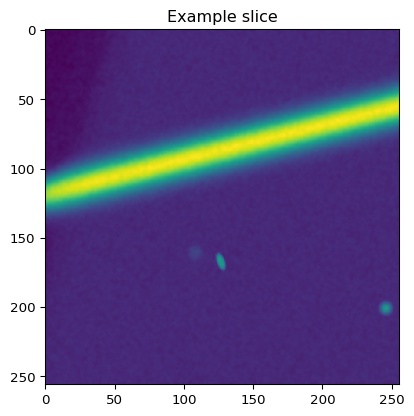

In [9]:
applyPipelineToSimulatedData = False

np.random.seed(5)

N = 256
M = 350
nclasses = 2
I, bbox, cl = gen_3D_GT(N, M, nclasses, thr_rel=0.15)

fig, ax = plt.subplots()
ax.imshow(I[I.shape[0] // 2,:,:,:].max(axis=-1))
ax.set_title(f'Example slice')

### Generate + save orthogonal views of the data (frames for the gif)

In [10]:
def gen_orthogonal_frames(I, bbox):
    """
    Generate N images containing the ith slice from each plane of the simulated volume I.
    """
    
    N = I.shape[0]
    M = bbox.shape[0]
    
    for slice_idx in np.arange(N):
        nrow, ncol = 1, 3
        fig, axs = plt.subplots(1,3,layout='tight')
        fig.set_size_inches(ncol*3, nrow*4)
        fig.suptitle(f'Orthogonal views of XYZ slices for idx {slice_idx}')
        for slice_ax in [0,1,2]:
    
            # Show a slice (max over channels) with contrast normalization
            if slice_ax == 0:
                img = I[slice_idx,:,:,:].max(axis=-1)  # (Y,X)
                slice_name = 'Z'
            elif slice_ax == 1:
                img = I[:,slice_idx,:,:].max(axis=-1)  # (Z,X)
                slice_name = 'Y'
            elif slice_ax == 2:
                img = I[:,:,slice_idx,:].max(axis=-1)  # (Z,Y)
                slice_name = 'X'
            else:
                raise Exception(f'Invalid slice_ax: {slice_ax}')
                
            Imin, Imax = np.percentile(img, (1, 99))
            img_disp = np.clip((img - Imin) / (Imax - Imin), 0, 1)
            
            axs[slice_ax].imshow(img_disp)
            axs[slice_ax].set_title(f'{slice_name}')
            axs[slice_ax].axis("off")
            
            count = 0
            for (x0, y0, z0, w, h, d) in bbox:
                # draw boxes that intersect this slice
                if slice_ax == 0 and z0 <= slice_idx < z0 + d:
                    axs[slice_ax].add_patch(Rectangle((x0, y0), w, h, fc = 'none', ec = 'k', linewidth=1.2))
                    count += 1
                elif slice_ax == 1 and y0 <= slice_idx < y0 + w:
                    axs[slice_ax].add_patch(Rectangle((x0, z0), h, d, fc = 'none', ec = 'k', linewidth=1.2))
                    count += 1
                elif slice_ax == 2 and x0 <= slice_idx < x0 + h:
                    axs[slice_ax].add_patch(Rectangle((y0, z0), w, d, fc = 'none', ec = 'k', linewidth=1.2))
                    count += 1
                else:
                    continue
            
            axs[slice_ax].text(5, 15, f"Boxes on slice: {count}", backgroundcolor = [1,1,1,0.5], fontsize=10, color='k')
        plt.savefig(os.path.join(outdir, f'idx_{slice_idx:03d}'))
    plt.close('all')

if False:
    # Generate + save N frames
    outdir = '/home/abenneck/Desktop/yolo3d_outputs/gif_frames_gt0'
    gen_orthogonal_frames(I, bbox)
    
    # Combine those N frames into a single .gif file
    for fname in sorted(os.listdir(outdir)):
        if '.ipynb' not in fname:
            img = imageio.imread(os.path.join(outdir, fname))
            frames.append(img)

    # NOTE: duration is the number of ms to display each frame
    imageio.mimsave('/home/abenneck/Desktop/yolo3d_outputs/gif_gt0.gif', frames, duration = 100, loop=0)

## (1.2) Apply our earlier pipeline to the simulated 3D dataset + quantify performance

### Apply 2D model to orthogonal slices

In [11]:
if applyPipelineToSimulatedData:
    model_path = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_saved_weights/modelsave_bright_on_dark.pt'
    # model_path = '/home/abenneck/Desktop/yolo_outputs/models/nepochs_9854/modelsave.pt'
    recon_xy, recon_xz, recon_yz = apply_model_to_orthogonal_slices(model_path, I)

### Downsample along the slice dimension

In [12]:
if applyPipelineToSimulatedData:
    down_xy, down_xz, down_yz = recon_down(recon_xy, recon_xz, recon_yz)

In [ ]:
print('recon_output.shape => downsampled_output.shape')
print(f'xy: {recon_xy.shape} => {down_xy.shape}')
print(f'xz: {recon_xz.shape} => {down_xz.shape}')
print(f'yz: {recon_yz.shape} => {down_yz.shape}')

### Generate MIP-volumes along each axis

In [14]:
if applyPipelineToSimulatedData:
    vol_0 = vol_to_mip_rgb(I, 0)
    vol_1 = vol_to_mip_rgb(I, 1)
    vol_2 = vol_to_mip_rgb(I, 2)

### Combine 3 2D outputs into 1 3D output

In [15]:
if applyPipelineToSimulatedData:
    recon_total = orthogonal_to_3D(down_xy, down_xz, down_yz)

### Visualize the outputs

In [16]:
if False and applyPipelineToSimulatedData:
    slice_idx = 15 # 0:31
    
    outdir = '/home/abenneck/Desktop/yolo3d_outputs/gif_frames_0'
    # for slice_idx in np.arange(down_dim):
    
    nrow, ncol = 2, 3
    fig, axs = plt.subplots(nrow, ncol, layout='constrained', sharex=True, sharey=True)
    axs[0,0].imshow(vol_0[slice_idx,:,:].max(axis=-1))
    axs[0,0].set_title(f'yz[{slice_idx},:,:]')
    axs[0,1].imshow(vol_1[:,slice_idx,:].max(axis=-1))
    axs[0,1].set_title(f'xz[:,{slice_idx},:]')
    axs[0,2].imshow(vol_2[:,:,slice_idx].max(axis=-1))
    axs[0,2].set_title(f'xy[:,:,{slice_idx}]')
    
    print('Plotting bboxes . . .')
    
    # conf_thresh = 0.0
    scores = recon_total[slice_idx,:,:,-4].ravel()
    scores[scores < conf_thresh] = 0.0
    predicted_rectangles = bb_to_rec(recon_total[slice_idx,:,:,:], pos = [4,2,5,3], fc='none', ec='r', alpha=scores)
    axs[1,0].imshow(vol_0[slice_idx,:,:].max(axis=-1))
    axs[1,0].add_collection(predicted_rectangles)
    
    scores = recon_total[:,slice_idx,:,-4].ravel()
    scores[scores < conf_thresh] = 0.0
    predicted_rectangles = bb_to_rec(recon_total[:,slice_idx,:,:], pos = [4,0,5,1], fc='none', ec='r', alpha=scores)
    axs[1,1].imshow(vol_1[:,slice_idx,:].max(axis=-1))
    axs[1,1].add_collection(predicted_rectangles)
    
    scores = recon_total[:,:,slice_idx,-4].ravel()
    scores[scores < conf_thresh] = 0.0
    predicted_rectangles = bb_to_rec(recon_total[:,:,slice_idx,:], pos = [2,0,3,1], fc='none', ec='r', alpha=scores)
    axs[1,2].imshow(vol_2[:,:,slice_idx].max(axis=-1))
    axs[1,2].add_collection(predicted_rectangles)
    
    fig.set_size_inches(ncol*3, nrow*3)
    # plt.savefig(os.path.join(outdir, f'recon_slice_{slice_idx:03d}.png'))

## (1.3) Quantify Model Performance wrt GT bboxes

In [6]:
def yolo_output_to_list(bb_grid):

    if len(bb_grid.shape) == 2:
        return bb_grid

    if len(bb_grid.shape) == 3:   
        bb_list = bb_grid.reshape(bb_grid.shape[0] * bb_grid.shape[1], bb_grid.shape[2])

    return bb_list

indir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax0'
data = np.load(os.path.join(indir, os.listdir(indir)[0]))
print(data.shape)
data_flat = yolo_output_to_list(data)
print(data_flat[0])

def get_mAP(gt_bboxes, pred_bboxes):

    # Compute IOU between gt_bboxes and pred_bboxes

    # Assign each gt_bbox to a pred_bbox, if applicable

    # Compute (P,R) points for c_thresh = 0:0.01:1 at each iou_thresh = 0:0.05:1

    # Compute AP as area under each PR curve
    AP = [0,0]
    
    return AP, np.mean(AP)

(2148, 1832, 8)
[-3.75 -2.75 -3.75 -2.75  0.    -inf  -inf  -inf]


## (1.4) The Complete Pipeline

In [ ]:
# Generate a synthetic dataset
np.random.seed(0)
N = 256
M = 350
nclasses = 2
I, bbox, cl = gen_3D_GT(N, M, nclasses, thr_rel=0.15)

# Apply our model to the orthogonal slices
# model_path = '/home/abenneck/Desktop/yolo_outputs/models/nepochs_9854/modelsave.pt'
model_path = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_saved_weights/modelsave_bright_on_dark.pt'
recon_xy, recon_xz, recon_yz = apply_model_to_orthogonal_slices(model_path, I)

# Downsample along the corresponding slice axis
down_xy, down_xz, down_yz = recon_down(recon_xy, recon_xz, recon_yz)

# Generate MIP-volumes for downstream visualization
vol_0 = vol_to_mip_rgb(I, 0)
vol_1 = vol_to_mip_rgb(I, 1)
vol_2 = vol_to_mip_rgb(I, 2)

# Combine the 3 orthogonal views into 1 3D view
recon_total = orthogonal_to_3D(down_xy, down_xz, down_yz)

# Quantify the performance of the model


### Visualize results on input image volume

Plotting bboxes . . .


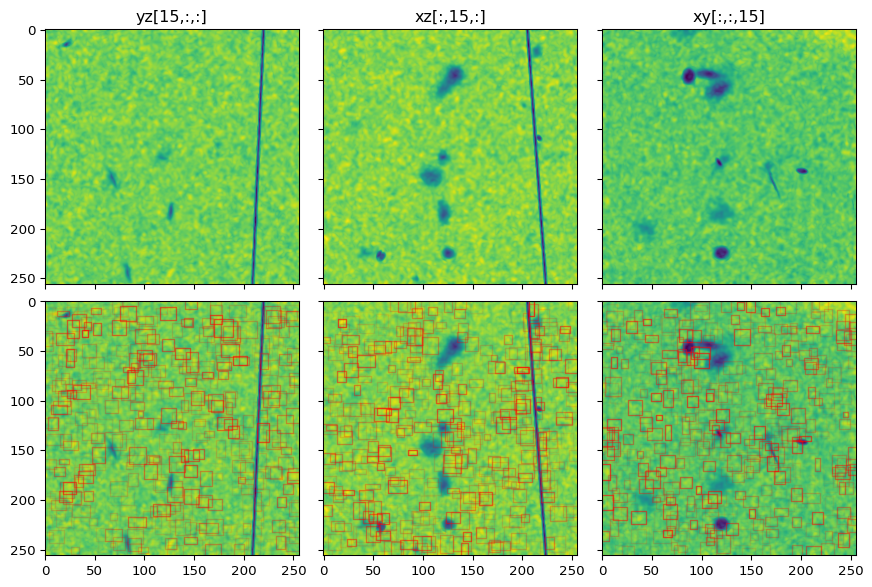

In [11]:
slice_idx = 15 # 0:31

outdir = '/home/abenneck/Desktop/yolo3d_outputs/gif_frames_0'
# for slice_idx in np.arange(down_dim):

nrow, ncol = 2, 3
fig, axs = plt.subplots(nrow, ncol, layout='constrained', sharex=True, sharey=True)
axs[0,0].imshow(vol_0[slice_idx,:,:].max(axis=-1))
axs[0,0].set_title(f'yz[{slice_idx},:,:]')
axs[0,1].imshow(vol_1[:,slice_idx,:].max(axis=-1))
axs[0,1].set_title(f'xz[:,{slice_idx},:]')
axs[0,2].imshow(vol_2[:,:,slice_idx].max(axis=-1))
axs[0,2].set_title(f'xy[:,:,{slice_idx}]')

print('Plotting bboxes . . .')

scores = recon_total[slice_idx,:,:,-4].ravel()
predicted_rectangles = bb_to_rec(recon_total[slice_idx,:,:,:], pos = [4,2,5,3], fc='none', ec='r', alpha=scores)
axs[1,0].imshow(vol_0[slice_idx,:,:].max(axis=-1))
axs[1,0].add_collection(predicted_rectangles)

scores = recon_total[:,slice_idx,:,-4].ravel()
predicted_rectangles = bb_to_rec(recon_total[:,slice_idx,:,:], pos = [4,0,5,1], fc='none', ec='r', alpha=scores)
axs[1,1].imshow(vol_1[:,slice_idx,:].max(axis=-1))
axs[1,1].add_collection(predicted_rectangles)

scores = recon_total[:,:,slice_idx,-4].ravel()
predicted_rectangles = bb_to_rec(recon_total[:,:,slice_idx,:], pos = [2,0,3,1], fc='none', ec='r', alpha=scores)
axs[1,2].imshow(vol_2[:,:,slice_idx].max(axis=-1))
axs[1,2].add_collection(predicted_rectangles)

fig.set_size_inches(ncol*3, nrow*3)
# plt.savefig(os.path.join(outdir, f'recon_slice_{slice_idx:03d}.png'))

# (2) Apply the above pipeline to real HDF5 data

## (2.0) Apply model to 2D slices from 3D volume, using tile method since images are relatively large

In [2]:
start_total = time.time()

# Laod 2D YOLO model
model_path = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_saved_weights/modelsave_bright_on_dark.pt'
net = Net()
net.load_state_dict(torch.load(model_path))
B = net.B
stride = net.stride

# Load HDF5 3D input image
fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
vol = h5py.File(fname)
vol_stack = vol['stack']
curr_ax = 1 # [0,1,2]
next_idx = 8587

# outdir = f'/home/abenneck/Desktop/yolo3d_outputs/Ex_488_Em_525/ax{curr_ax}'
outdir = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}'

for idx in np.arange(vol_stack.shape[curr_ax]):

    if idx < next_idx:
        continue

    # Extract the slice 
    if curr_ax == 0:
        img = vol_stack[idx,:,:]
        out_fname = os.path.split(fname)[-1][:-3] + f'idx_{idx:05d}_:_:.npy'
    elif curr_ax == 1:
        img = vol_stack[:,idx,:]
        out_fname = os.path.split(fname)[-1][:-3] + f'idx_:_{idx:05d}_:.npy'
    elif curr_ax == 2:
        img = vol_stack[:,:,idx]
        out_fname = os.path.split(fname)[-1][:-3] + f'idx_:_:_{idx:05d}.npy'
    else:
        raise Exception(f'Invalid ax ({curr_ax}) supplied, only ({[k for k in range(2)]}) allowed')

    # Preprocess using gamma correction + upsampling
    start = time.time()
    img_up = preprocess(img)
    print(f'Finished preprocessing in {time.time()-start:.2f}s')
    
    # Extract tiles from the preprocessed input image
    padded_img, tiles = img_to_tiles(img_up, lower_threshold_bg = 0.04, verbose=True)
    
    # Apply model to tiles + apply bbox edge filtering
    print('Applying model to tiles . . .')
    out = apply_model_to_tiles(tiles, model_path, padded_img.shape[0], padded_img.shape[1], verbose=True)

    # Convert the raw model output into a more useful data structure
    print('Postprocessing . . .')
    pads = (np.array(padded_img.shape) - np.array(img_up.shape))/2
    out = torch.tensor(out.clone().detach(), dtype=torch.float32)
    out = postprocess(out, B, stride, pads, up_factor=2, verbose=True)

    # Save the processed output
    out_path = os.path.join(outdir, out_fname)
    if True:
        np.save(out_path, out)

    # # (11/19/25) Save some additional metadata in an npz file
    # out_fnamez = (img_path.split('/')[-1]).split('.')[0] + '_metadata.npz'
    # out_pathz = os.path.join(outdir, out_fnamez)
    # if False:
    #     np.savez(out_pathz,
    #             units = 'um',
    #             nrow_orig_img = img.shape[0],
    #             ncol_orig_img = img.shape[1],
    #             drow_orig_img = 1.866,
    #             dcol_orig_img = 1.866,
    #             dslice_orig_img = 2.0,
    #             nrow_upsampled_img = img_up.shape[0],
    #             ncol_upsampled_img = img_up.shape[1], 
    #             drow_upsampled_img = 3.732,
    #             dcol_upsampled_img = 3.732,
    #             pad_row_top = pads[0],
    #             pad_row_bot = pads[0],
    #             pad_col_left = pads[1],
    #             pad_col_right = pads[1],
    #             nrow = out.shape[0],
    #             ncol = out.shape[1],
    #             drow = 7.464,
    #             dcol = 7.464,
    #             note = "Bbox coords refer to the original image, with (0,0) corresponding to the top left pixel center"
    #             )    
        
    print(f'Saved the outputs for image {idx}/{vol_stack.shape[curr_ax]} in {time.time()-start_total:.2f}s\n')
    start_total = time.time()



Finished preprocessing in 1.19s
Finished extracting all tiles in 3.13s
Applying model to tiles . . .
Finished tiles 0:100/2178 in 0.28s
Finished tiles 100:300/2178 in 0.90s
Finished applying model to entire image in 5.02s with 204/2178 (0.094) tiles marked as foreground
Postprocessing . . .
Finished postprocessing in 0.11s


/tmp/ipykernel_399209/1616186617.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out = torch.tensor(out.clone().detach(), dtype=torch.float32)


Saved the outputs for image 8429/8587 in 36.27s

Finished preprocessing in 1.23s
Finished extracting all tiles in 3.14s
Applying model to tiles . . .
Finished tiles 0:100/2178 in 0.27s
Finished tiles 100:300/2178 in 0.94s
Finished applying model to entire image in 4.52s with 172/2178 (0.079) tiles marked as foreground
Postprocessing . . .
Finished postprocessing in 0.12s
Saved the outputs for image 8430/8587 in 10.38s

Finished preprocessing in 1.37s
Finished extracting all tiles in 3.65s
Applying model to tiles . . .
Finished tiles 0:100/2178 in 1.02s
Finished tiles 100:300/2178 in 1.62s
Finished applying model to entire image in 6.77s with 151/2178 (0.069) tiles marked as foreground
Postprocessing . . .
Finished postprocessing in 0.21s
Saved the outputs for image 8431/8587 in 62.59s

Finished preprocessing in 2.15s
Finished extracting all tiles in 4.21s
Applying model to tiles . . .
Finished tiles 0:100/2178 in 0.36s
Finished tiles 100:300/2178 in 1.87s
Finished applying model to ent

## (2.1) Downsample each dataset along the 'slice' dimension

In [ ]:
# curr_ax, idx_start = 0, 3600
# curr_ax, idx_start = 1, 8587
curr_ax, idx_start = 2, 7321

indir = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}'
outdir = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}_down'
conf_idx = 4
n_files = len(os.listdir(indir))
ds_factor = 4

ds_count = 0
recon_down = []
time_start = time.time()

for idx, fname in enumerate(sorted(os.listdir(indir))):

    if idx < idx_start:
        continue
    
    # Increment count for current number of slices in the "to-be-downsampled" stack
    ds_count += 1

    # Load slice data
    data = np.load(os.path.join(indir, fname))

    # Append slice to the stack before downsampling
    recon_down.append(data)

    # Downsample every 'ds_factor' (4) slices
    if ds_count == ds_factor:
        recon_down = np.stack(recon_down)
        inds = np.argmax(recon_down[..., conf_idx], axis = 0)
        recon_down_out = np.take_along_axis(recon_down, inds[None, :, :, None], axis=0)
        recon_down_out = recon_down_out[0]
        
        # Save downsampled output
        out_fname = fname[:30] + f'_ax{curr_ax}_{idx-3:05d}:{idx:05d}.npy'
        np.save(os.path.join(outdir, out_fname), recon_down_out)
        print(f'Downsampled slices {idx-3}-{idx}/{n_files} in {time.time()-time_start:.02f}s and saved outputs at {out_fname}')
        # break
        
        # Reset counts + empty the primary data structure
        time_start = time.time()
        recon_down = []
        ds_count = 0

### Plot the Results

In [ ]:
# Set parameters
ds_factor = 4
curr_ax = 2 # [0,1,2]
orig_slice_idx = 3500 # {0:[0,3600],1:[0,8587],2:[0,7321]}
out_slice_idx = int(orig_slice_idx/ds_factor)

# Load HDF5 3D input image
if curr_ax == 0:
    fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
    vol = h5py.File(fname)
    vol_stack = vol['stack']
    img = vol_stack[orig_slice_idx, :, :]
    img_title = f'original[{orig_slice_idx},:,:]'
    img_mip = vol_to_mip(vol_stack, curr_ax, ds_factor = 4, slice_idx = orig_slice_idx)
    img_mip_title = f'MIP[{out_slice_idx},:,:] = max(original[{orig_slice_idx}:{orig_slice_idx+4},:,:], axis={curr_ax})'
    slice_fname = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}/Ex_488_Em_525_stitched_chunk32idx_{orig_slice_idx:05d}_:_:.npy'
elif curr_ax == 1:
    fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
    vol = h5py.File(fname)
    vol_stack = vol['stack']
    img = vol_stack[:, orig_slice_idx, :]
    img_title = f'original[:,{orig_slice_idx},:]'
    img_mip = vol_to_mip(vol_stack, curr_ax, ds_factor = 4, slice_idx = orig_slice_idx)
    img_mip_title = f'MIP[:,{out_slice_idx},:] = max(original[:,{orig_slice_idx}:{orig_slice_idx+4},:], axis={curr_ax})'
    slice_fname = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}/Ex_488_Em_525_stitched_chunk32idx_:_{orig_slice_idx:05d}_:.npy'
else: # curr_ax = 2
    fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_full_sag.h5'
    vol = h5py.File(fname)
    vol_stack = vol['stack']
    img = vol_stack[:, :, orig_slice_idx]
    img_title = f'original[:,:,{orig_slice_idx}]'
    img_mip = vol_to_mip(vol_stack, curr_ax, ds_factor = 4, slice_idx = orig_slice_idx)
    img_mip_title = f'MIP[:,:,{out_slice_idx}] = max(original[:,:,{orig_slice_idx}:{orig_slice_idx+4}], axis={curr_ax})'    
    slice_fname = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}/Ex_488_Em_525_stitched_full_sagidx_:_:_{orig_slice_idx:05d}.npy'
print('Finished loading images')    

# Load output files
recon_orig = np.load(slice_fname)
slice_fname_ds = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}_down/Ex_488_Em_525_stitched_full_sa_ax{curr_ax}_{orig_slice_idx:05d}:{orig_slice_idx+3:05d}.npy'
recon_ds = np.load(slice_fname_ds)
print('Finished loading outputs')    

# Generate visualization
fig, axs = plt.subplots(2, 2, layout='constrained', sharex=True, sharey=True)
axs[0,0].imshow(img)
axs[0,0].set_title(img_title)

time_start = time.time()
scores = recon_orig[:,:,-4].ravel()
predicted_rectangles = bb_to_rec(recon_orig, fc='none', ec='lime', alpha=scores)
axs[1,0].imshow(img)
axs[1,0].add_collection(predicted_rectangles)
print(f'Finished orig bboxes in {time.time()-time_start:.02f}s')

axs[0,1].imshow(img_mip)
axs[0,1].set_title(img_mip_title)

time_start = time.time()
scores = recon_ds[:,:,-4].ravel()
predicted_rectangles = bb_to_rec(recon_ds, fc='none', ec='lime', alpha=scores)
axs[1,1].imshow(img_mip)
axs[1,1].add_collection(predicted_rectangles)
print(f'Finished ds bboxes in {time.time()-time_start:.02f}s')

for ax_i in axs:
    for ax in ax_i:
        # ax.set_xlim([4500,4750])
        # ax.set_ylim([1250,1000])
        # ax.set_xlim([5000,5250])
        # ax.set_ylim([1250,1000])
        ax.set_xlim([1750,1800])
        ax.set_ylim([2950,2900])

fig.set_size_inches(7,7)

## (2.2) Stitch together downsampled slices + save ijk cubes

In [ ]:
outdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/cubes'

indir0 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax0_down'
data0 = np.load(os.path.join(indir0,os.listdir(indir0)[0]))
shape0 = data0.shape

indir1 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax1_down'
data1 = np.load(os.path.join(indir1,os.listdir(indir1)[0]))
shape1 = data1.shape

indir2 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax2_down'
data2 = np.load(os.path.join(indir2,os.listdir(indir2)[0]))
shape2 = data2.shape

out_dim = 256
final_shape = np.array([shape1[0], shape0[0], shape0[1]])
bbox_dim = 7 # Used to init 3D recon
num_classes = 3 # Used to init 3D recon

n_cube_i = final_shape[0] // out_dim # Num complete cubes along respective axis
n_cube_j = final_shape[1] // out_dim # Num complete cubes along respective axis
n_cube_k = final_shape[2] // out_dim # Num complete cubes along respective axis

next_i = 2
next_j = 5
next_k = 3

# Load 256 slices from each dir, stack them into 3 volumes, and combine the volumes into a 3D representation
for i in np.arange(n_cube_i + 1): # (+1) added to include edge case cubes
    
    if i < next_i:
        continue
        
    for j in np.arange(n_cube_j + 1):
        
        if j < next_j and i <= next_i:
            continue
            
        for k in np.arange(n_cube_k + 1):

            if k < next_k and i <= next_i and j <= next_j:
                continue

            # If cube lies on edge of volume, adjust relative idx accordingly
            edge_str = 'edge ' if i == n_cube_i or j == n_cube_j or k == n_cube_k else ''
            edge_i_end_idx = final_shape[0] if i == n_cube_i else (i+1)*(out_dim)
            edge_j_end_idx = final_shape[1] if j == n_cube_j else (j+1)*(out_dim)
            edge_k_end_idx = final_shape[2] - 2 if k == n_cube_k else (k+1)*(out_dim)
            # print(f'End idx: ({edge_i_end_idx}, {edge_j_end_idx}, {edge_k_end_idx})')
            
            print(f'Starting {edge_str}cube ({i},{j},{k}) . . .')
            time_total = time.time()
            
            # Load and stack outputs from ax0 slices
            time_start = time.time()
            out_stack0 = []
            count0 = 0
            idx_start0 = i*out_dim
            for idx, fname in enumerate(sorted(os.listdir(indir0))):
                if idx < idx_start0:
                    continue
                out_slice = np.memmap(os.path.join(indir0,fname), dtype=np.float32, shape = shape0)

                # TODO: Extract relevant 256x256 image from whole image before adding image to the stack
                out_slice = out_slice[(j*out_dim):edge_j_end_idx,(k*out_dim):edge_k_end_idx,:]
                out_stack0.append(out_slice)
            
                count0 += 1
                if count0 == out_dim:
                    count0 = 0
                    break
            out_stack0 = np.stack(out_stack0, axis = 0)
            print(f'Finished ax0 in {time.time()-time_start:.2f}s with shape {out_stack0.shape}')

            # Load and stack outputs from ax1 slices
            time_start = time.time()
            out_stack1 = []
            count1 = 0
            idx_start1 = j*out_dim
            for idx, fname in enumerate(sorted(os.listdir(indir1))):
                if idx < idx_start1:
                    continue
                out_slice = np.memmap(os.path.join(indir1,fname), dtype=np.float32, shape = shape1)
                
                # TODO: Extract relevant 256x256 image from whole image before adding image to the stack
                out_slice = out_slice[(i*out_dim):edge_i_end_idx,(k*out_dim):edge_k_end_idx,:]
                out_stack1.append(out_slice)
            
                count1 += 1
                if count1 == out_dim:
                    count1 = 0
                    break
            out_stack1 = np.stack(out_stack1, axis = 0).transpose(1,0,2,3)
            print(f'Finished ax1 in {time.time()-time_start:.2f}s with shape {out_stack1.shape}')

            # Load and stack outputs from ax2 slices
            time_start = time.time()
            out_stack2 = []
            count2 = 0
            idx_start2 = k*out_dim
            for idx, fname in enumerate(sorted(os.listdir(indir2))):
                if idx < idx_start2:
                    continue
                out_slice = np.memmap(os.path.join(indir2,fname), dtype=np.float32, shape = shape2)
                
                # TODO: Extract relevant 256x256 image from whole image before adding image to the stack
                out_slice = out_slice[(i*out_dim):edge_i_end_idx,(j*out_dim):edge_j_end_idx,:]
                out_stack2.append(out_slice)
            
                count2 += 1
                if count2 == out_dim:
                    count2 = 0
                    break
            out_stack2 = np.stack(out_stack2, axis = 0).transpose(1,2,0,3)
            print(f'Finished ax2 in {time.time()-time_start:.2f}s with shape {out_stack2.shape}')

            # Combine the 3 volumes into 1 volume where each elem is a bounding cube
            i_lim = final_shape[0] % out_dim - 1 if i == n_cube_i else out_dim
            j_lim = final_shape[1] % out_dim - 3 if j == n_cube_j else out_dim
            k_lim = final_shape[2] % out_dim - 2 if k == n_cube_k else out_dim
            # print(i_lim, j_lim, k_lim)
            recon_total = np.ones((out_dim, out_dim, out_dim, bbox_dim+num_classes))*(-np.inf)
            for i_ in np.arange(i_lim):
                for j_ in np.arange(j_lim):
                    for k_ in np.arange(k_lim):

                        xmin = (out_stack2[i_,j_,k_,1] + out_stack1[i_,j_,k_,1]) / 2
                        xmax = (out_stack2[i_,j_,k_,3] + out_stack1[i_,j_,k_,3]) / 2
                        ymin = (out_stack2[i_,j_,k_,0] + out_stack0[i_,j_,k_,1]) / 2
                        ymax = (out_stack2[i_,j_,k_,2] + out_stack0[i_,j_,k_,3]) / 2
                        zmin = (out_stack1[i_,j_,k_,0] + out_stack0[i_,j_,k_,0]) / 2
                        zmax = (out_stack1[i_,j_,k_,2] + out_stack0[i_,j_,k_,2]) / 2
                        
                        conf = np.min([out_stack0[i_,j_,k_,4], out_stack1[i_,j_,k_,4], out_stack2[i_,j_,k_,4]])
                        
                        cl0 = np.mean([out_stack0[i_,j_,k_,5], out_stack1[i_,j_,k_,5], out_stack2[i_,j_,k_,5]])
                        cl1 = np.mean([out_stack0[i_,j_,k_,6], out_stack1[i_,j_,k_,6], out_stack2[i_,j_,k_,6]])
                        cl2 = np.mean([out_stack0[i_,j_,k_,7], out_stack1[i_,j_,k_,7], out_stack2[i_,j_,k_,7]])
                        
                        recon_total[i_,j_,k_] = [xmin, xmax, ymin, ymax, zmin, zmax, conf, cl0, cl1, cl2]
            
            # Save output cube using ijk format in fname
            out_fname = f'i{i:04d}_j{j:04d}_k{k:04d}_d{out_dim}_Ex_488_Em_525.npy'
            # out_fname = f'i{i:04d}_j{j:04d}_k{k:04d}_di{ilim}_dj{j_lim}_dk{k_lim}_Ex_488_Em_525.npy'
            np.save(os.path.join(outdir, out_fname), recon_total)
            print(f'Saved cube ({i},{j},{k}) in {time.time()-time_total:.2f}s as {out_fname} in {outdir}\n')

            # break
        # break
    # break


### Plot Results

In [ ]:
# Set key parameters
ds_factor = 4
out_dim = 256
orig_slice_dim = out_dim * ds_factor
mid_slice_dim = int(orig_slice_dim / 2)
shift = 768

# Load output data cube + extract data from relevant slices
time_start = time.time()
outdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/cubes'
i, j, k = 2, 3, 3
out_fname = f'i{i:04d}_j{j:04d}_k{k:04d}_d{out_dim}_Ex_488_Em_525.npy'
data = np.load(os.path.join(outdir, out_fname))

orig_slice_idx0 = (i*1024)+512 # Idx of the first img slice in the stack to be downsampled, from the middle of ax0
down_slice_idx0 = int((orig_slice_idx0 % 1024) / ds_factor)
data0 = data[down_slice_idx0,:,:,:]

orig_slice_idx1 = (j*1024)+512 # Idx of the first img slice in the stack to be downsampled, from the middle of ax1
down_slice_idx1 = int((orig_slice_idx1 % 1024) / ds_factor)
data1 = data[:,down_slice_idx1,:,:]

orig_slice_idx2 = (k*1024)+512 # Idx of the first img slice in the stack to be downsampled, from the middle of ax2
down_slice_idx2 = int((orig_slice_idx2 % 1024) / ds_factor)
data2 = data[:,:,down_slice_idx2,:]
print(f'Finished loading bbox data in {time.time()-time_start:.2f}s')

# Load original HDF5 3D images + convert to MIPs for visualization
time_start = time.time()
fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
vol = h5py.File(fname)
vol_stack = vol['stack']
img_mip0 = vol_to_mip(vol_stack, 0, ds_factor = 4, slice_idx = orig_slice_idx0)

fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
vol = h5py.File(fname)
vol_stack = vol['stack']
img_mip1 = vol_to_mip(vol_stack, 1, ds_factor = 4, slice_idx = orig_slice_idx1)

fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_full_sag.h5'
vol = h5py.File(fname)
vol_stack = vol['stack']
img_mip2 = vol_to_mip(vol_stack, 2, ds_factor = 4, slice_idx = orig_slice_idx2)
print(f'Finished loading images in {time.time()-time_start:.2f}s')

# Initialize output figure
time_start = time.time()
nrow, ncol = 6,1
fig, axs = plt.subplots(nrow, ncol, layout='constrained')
axs[0].imshow(img_mip0)
axs[0].add_patch(Rectangle((orig_slice_idx1-512,orig_slice_idx2-512),1024-shift,1024-shift,fc='none',ec='r'))
axs[0].set_title(f'ax0=yz[{orig_slice_idx0},:,:]')
axs[2].imshow(img_mip1)
axs[2].set_title(f'ax1=xz[:,{orig_slice_idx1},:]')
axs[2].add_patch(Rectangle((orig_slice_idx2-512,orig_slice_idx0-512),1024-shift,1024-shift,fc='none',ec='r'))
axs[4].imshow(img_mip2)
axs[4].set_title(f'ax2=xy[:,:,{orig_slice_idx2}]')
axs[4].add_patch(Rectangle((orig_slice_idx1-512,orig_slice_idx0-512),1024-shift,1024-shift,fc='none',ec='r'))

print('Plotting bboxes . . .')

scores = data0[:,:,-4].ravel()
predicted_rectangles = bb_to_rec(data0, pos = [4,2,5,3], fc='none', ec='lime', alpha=scores)
axs[1].imshow(img_mip0)
axs[1].add_collection(predicted_rectangles)
axs[1].set_xlim([orig_slice_idx1-512, orig_slice_idx1+512-shift])
axs[1].set_ylim([orig_slice_idx2-512, orig_slice_idx2+512-shift])

scores = data1[:,:,-4].ravel()
predicted_rectangles = bb_to_rec(data1, pos = [4,0,5,1], fc='none', ec='lime', alpha=scores)
axs[3].imshow(img_mip1)
axs[3].add_collection(predicted_rectangles)
axs[3].set_xlim([orig_slice_idx2-512, orig_slice_idx2+512-shift])
axs[3].set_ylim([orig_slice_idx0-512, orig_slice_idx0+512-shift])

scores = data2[:,:,-4].ravel()
predicted_rectangles = bb_to_rec(data2, pos = [2,0,3,1], fc='none', ec='lime', alpha=scores)
axs[5].imshow(img_mip2)
axs[5].add_collection(predicted_rectangles)
axs[5].set_xlim([orig_slice_idx1-512, orig_slice_idx1+512-shift])
axs[5].set_ylim([orig_slice_idx0-512, orig_slice_idx0+512-shift])

fig.set_size_inches(ncol*8, nrow*5)
# plt.savefig(os.path.join(outdir, f'recon_slice_{slice_idx:03d}.png'))
print(f'Finished plotting everything in {time.time()-time_start:.2f}s')

if False:
    fig.savefig(os.path.join('/home/abenneck/Desktop/yolo3d_outputs/','slices_cube_i2_j3_k3_refined2.jpg'))

## (2.3) Max pool ijk cubes n times by a factor of 2